Step 1: Import all necessary libraries

In [123]:
# Step 1: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Step 2: Load and explore the dataset

In [124]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (7043, 21)

First few rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step 3: Data cleaning and preprocessing


In [125]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Convert TotalCharges to numeric (handling empty strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check again for missing values after conversion
print("\nMissing values after conversion:")
print(df.isnull().sum())

# Drop rows with missing values (only 11 rows)
df.dropna(subset=['TotalCharges'], inplace=True)

# Check data types
print("\nData types:")
print(df.info())

Missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Missing values after conversion:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11


# Step 4: Exploratory Data Analysis (EDA)

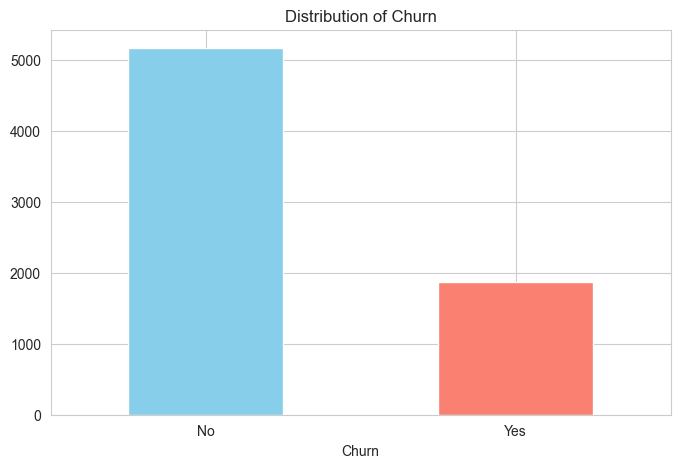

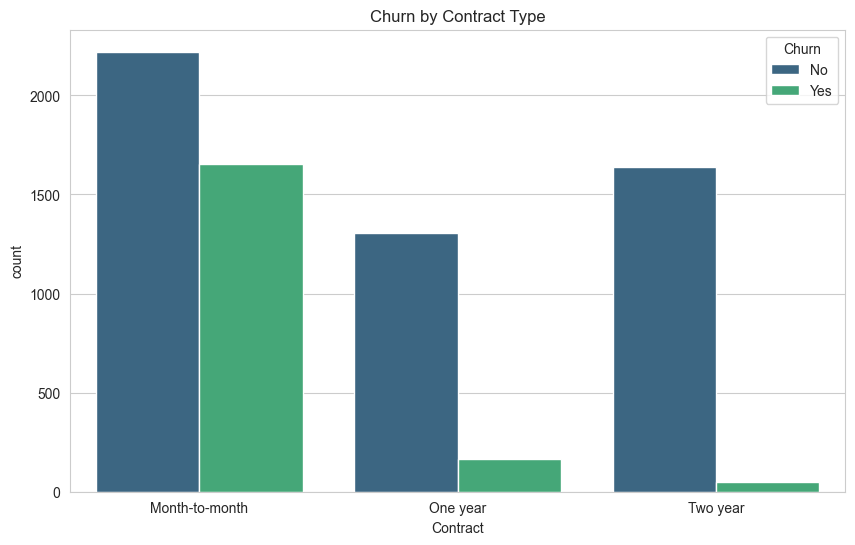

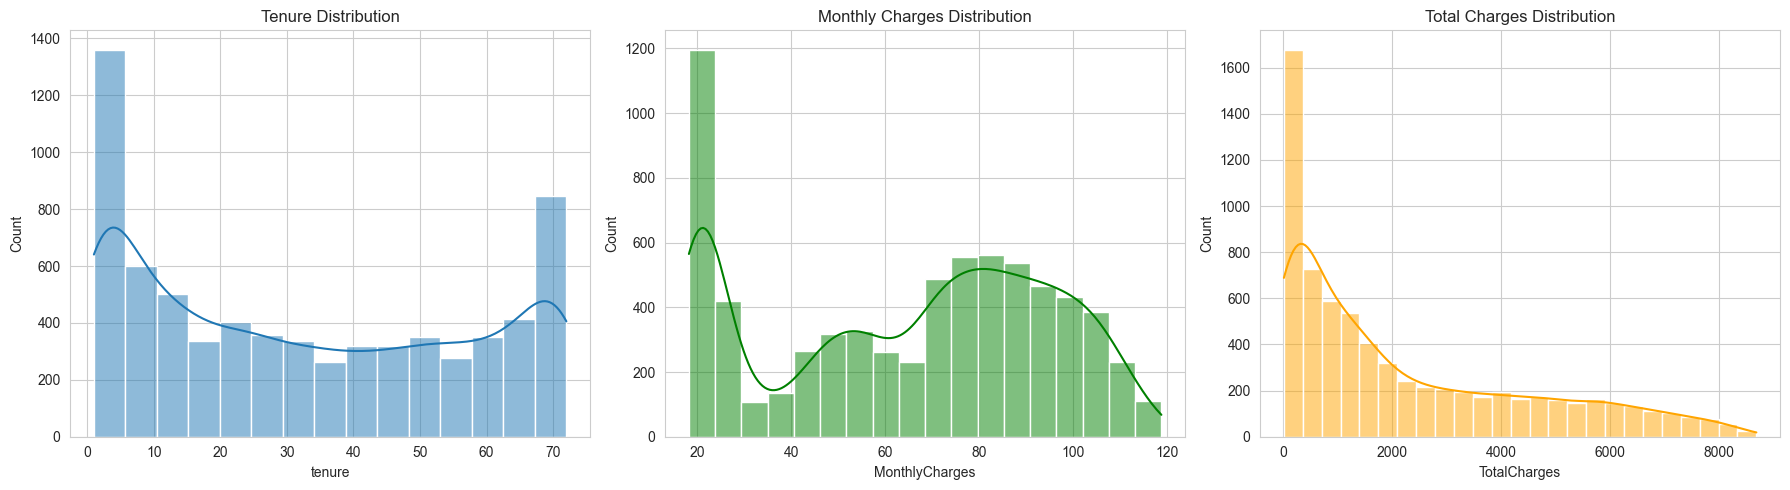

In [126]:


# Plot the target variable 'Churn'
plt.figure(figsize=(8, 5))
df['Churn'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Churn')
plt.xticks(rotation=0)
plt.show()

# Plot churn by contract type
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Churn by Contract Type')
plt.show()

# Plot numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['tenure'], ax=axes[0], kde=True)
axes[0].set_title('Tenure Distribution')
sns.histplot(df['MonthlyCharges'], ax=axes[1], kde=True, color='green')
axes[1].set_title('Monthly Charges Distribution')
sns.histplot(df['TotalCharges'], ax=axes[2], kde=True, color='orange')
axes[2].set_title('Total Charges Distribution')
plt.tight_layout()
plt.show()

# Step 5: Feature Engineering


In [127]:

# Create a "Value" Feature: Cost per month of service
df['CostPerTenure'] = df['TotalCharges'] / (df['tenure'] + 1)  # +1 to avoid division by zero

# Create a "Customer Stability" Score based on contract and payment method
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
payment_map = {
    'Electronic check': 0,
    'Mailed check': 1,
    'Bank transfer (automatic)': 2,
    'Credit card (automatic)': 2
}
df['ContractScore'] = df['Contract'].map(contract_map)
df['PaymentScore'] = df['PaymentMethod'].map(payment_map)
df['StabilityScore'] = df['ContractScore'] + df['PaymentScore']


# Bin tenure into customer lifecycle groups
df['TenureGroup'] = pd.cut(df['tenure'],
                           bins=[0, 12, 24, 48, 72, np.inf],
                           labels=['New(0-1y)', 'Established(1-2y)', 'Senior(2-4y)', 'Veteran(4-6y)', 'Legend(6y+)'])


# Interaction Feature: High monthly cost but low tenure is a risk factor
df['HighSpenderNew'] = ((df['MonthlyCharges'] > df['MonthlyCharges'].median()) &
                        (df['tenure'] < 12)).astype(int)

# Encode target variable
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Drop customerID as it's a unique identifier
df.drop('customerID', axis=1, inplace=True)

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'TenureGroup' not in categorical_cols:
    categorical_cols.append('TenureGroup')
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'CostPerTenure', 'StabilityScore', 'HighSpenderNew']

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']
Numerical columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'CostPerTenure', 'StabilityScore', 'HighSpenderNew']


# Step 6: Encode categorical variables

In [128]:

df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


print(f"Final dataset shape: {df_final.shape}")
df_final.head()

Final dataset shape: (7032, 40)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,CostPerTenure,ContractScore,PaymentScore,StabilityScore,HighSpenderNew,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_Established(1-2y),TenureGroup_Senior(2-4y),TenureGroup_Veteran(4-6y),TenureGroup_Legend(6y+)
0,0,1,29.85,29.85,0,14.925000,0,0,0,0,...,False,False,True,False,True,False,False,False,False,False
1,0,34,56.95,1889.50,0,53.985714,1,1,2,0,...,True,False,False,False,False,True,False,True,False,False
2,0,2,53.85,108.15,1,36.050000,0,1,1,0,...,False,False,True,False,False,True,False,False,False,False
3,0,45,42.30,1840.75,0,40.016304,1,2,3,0,...,True,False,False,False,False,False,False,True,False,False
4,0,2,70.70,151.65,1,50.550000,0,0,0,1,...,False,False,True,False,True,False,False,False,False,False



# Step 7: Split the data into training and testing sets

In [129]:

X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (5625, 39)
Testing set shape: (1407, 39)


# Step 8: Scale numerical features

In [130]:

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Save the scaler for later use
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as 'scaler.pkl'")

Scaler saved as 'scaler.pkl'


# Step 9: Handle class imbalance with SMOTE

In [131]:

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Class distribution before SMOTE: {np.bincount(y_train)}")
print(f"Class distribution after SMOTE: {np.bincount(y_train_resampled)}")

Class distribution before SMOTE: [4130 1495]
Class distribution after SMOTE: [4130 4130]


# Step 10: Train and evaluate models


In [132]:

# Initialize models
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

# Train models on resampled data
print("Training Random Forest...")
rf_model.fit(X_train_resampled, y_train_resampled)

print("Training XGBoost...")
xgb_model.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

Training Random Forest...
Training XGBoost...


# Step 11: Evaluate models

In [133]:


# Evaluate Random Forest
print("--- Random Forest Results ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}\n")

# Evaluate XGBoost
print("--- XGBoost Results ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

--- Random Forest Results ---
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1033
           1       0.55      0.64      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.77      1407

ROC-AUC Score: 0.8151

--- XGBoost Results ---
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1033
           1       0.53      0.63      0.58       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.70      1407
weighted avg       0.77      0.76      0.76      1407

ROC-AUC Score: 0.8119


# Step 12: Visualization of results

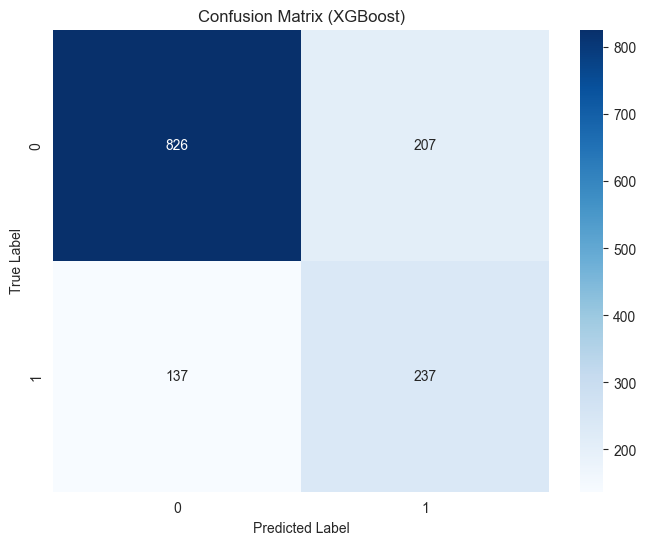

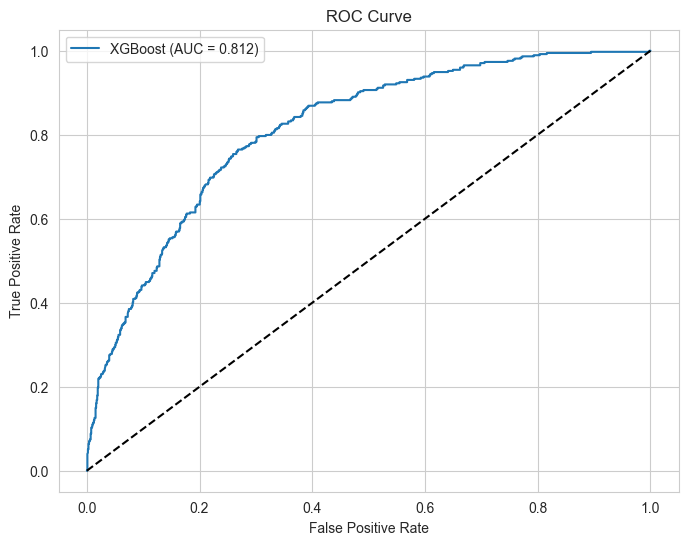

In [134]:


# Plot Confusion Matrix for XGBoost
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (XGBoost)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Plot ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_pred_proba_xgb):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Step 13: Feature importance analysis

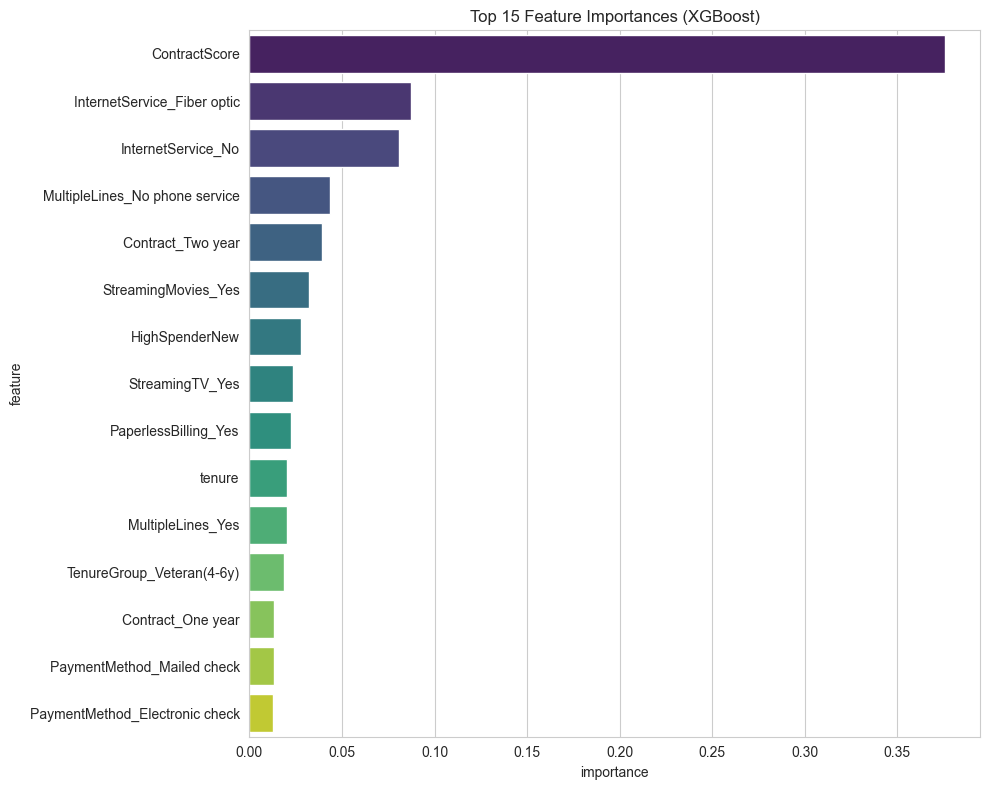

In [135]:


# Get feature importances from XGBoost
feature_importance = xgb_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False).head(15)

# Plot feature importance
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

# Step 14: Save the model and feature list

In [136]:

joblib.dump(xgb_model, 'churn_prediction_model.pkl')
joblib.dump(X_train.columns, 'model_columns.pkl')

print("Model saved as 'churn_prediction_model.pkl'")
print("Feature list saved as 'model_columns.pkl'")

Model saved as 'churn_prediction_model.pkl'
Feature list saved as 'model_columns.pkl'


# Step 15: Create a simple prediction function for demonstration

In [137]:

def predict_churn(customer_data):
    """
    Predict churn for a new customer
    customer_data: Dictionary with customer features
    """
    # Load the model and feature list
    model = joblib.load('churn_prediction_model.pkl')
    model_columns = joblib.load('model_columns.pkl')
    scaler = joblib.load('scaler.pkl')
    
    # Create a DataFrame from the input
    input_df = pd.DataFrame([customer_data])
    
    # Ensure all required columns are present
    for col in model_columns:
        if col not in input_df.columns:
            input_df[col] = 0
    
    # Reorder columns to match training data
    input_df = input_df[model_columns]
    
    # Scale numerical features
    input_df[numerical_cols] = scaler.transform(input_df[numerical_cols])
    
    # Make prediction
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]
    
    return {
        'churn_prediction': 'Yes' if prediction == 1 else 'No',
        'churn_probability': probability
    }

# Example usage (this is just a template - you would need real data)
example_customer = {
    'tenure': 12,
    'MonthlyCharges': 70.50,
    'TotalCharges': 850.00,
    # Add all other features with appropriate values
}

# Note: You would need to fill in all feature values for a real prediction
print("Prediction function created. Use predict_churn(customer_data) for new predictions.")

Prediction function created. Use predict_churn(customer_data) for new predictions.
